<!-- bootcamp-header: generated by tools/build_headers.py, edit the README timetable instead -->
# Solutions: pandas

Worked solutions to the exercises in [`13_EX_Pandas.ipynb`](https://github.com/mikekestemont/dtaantwerp26-27.github.io/blob/DTA_Bootcamp_2026_students/exercises/questions/13_EX_Pandas.ipynb), which go with the session [`13_W3_Wed_Pandas.ipynb`](https://github.com/mikekestemont/dtaantwerp26-27.github.io/blob/DTA_Bootcamp_2026_students/notebooks/13_W3_Wed_Pandas.ipynb).  

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mikekestemont/dtaantwerp26-27.github.io/blob/DTA_Bootcamp_2026_students/exercises/solutions/13_SOL_Pandas.ipynb)

In [ ]:
# Run this cell only if you are working on Google Colab: it downloads the course
# material (notebooks and data) so that the file paths in this notebook work.
# On your own computer you can skip it.
!git clone --quiet --depth 1 --branch DTA_Bootcamp_2026_students https://github.com/mikekestemont/dtaantwerp26-27.github.io.git bootcamp
%cd bootcamp/exercises/solutions

Every exercise is followed by one possible solution (sometimes two). Other correct solutions exist: what matters is that yours works and that you understand why.

## Core exercises

### 1. Load and inspect (basic)

Import `pandas`, load `titanic.csv` into `df` and answer with one line each: how many rows and columns; the names of the columns; the first three rows; the number of missing values per column.

In [1]:
import pandas as pd

df = pd.read_csv('../../data/titanic.csv')

print(df.shape)
print(list(df.columns))
print(df.head(3))
print(df.isna().sum())

(891, 12)
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          68

### 2. One column (basic)

Select the `Fare` column and print its mean, median and maximum, rounded to two decimals. How many *different* fares were paid (`.nunique()`)?

In [2]:
fare = df['Fare']
print(round(fare.mean(), 2), round(fare.median(), 2), round(fare.max(), 2))
print(fare.nunique())

32.2 14.45 512.33
248


### 3. Who? (standard)

Print the name of the youngest passenger and of the passenger who paid the highest fare (`.idxmin()` / `.idxmax()` with `.loc[]`). Then show the five oldest passengers with their name, age and class, using `.sort_values()`.

In [3]:
print(df.loc[df['Age'].idxmin(), 'Name'])
print(df.loc[df['Fare'].idxmax(), 'Name'])
print(df.sort_values('Age', ascending=False)[['Name', 'Age', 'Pclass']].head())

Thomas, Master. Assad Alexander
Ward, Miss. Anna
                                     Name   Age  Pclass
630  Barkworth, Mr. Algernon Henry Wilson  80.0       1
851                   Svensson, Mr. Johan  74.0       3
493               Artagaveytia, Mr. Ramon  71.0       1
96              Goldschmidt, Mr. George B  71.0       1
116                  Connors, Mr. Patrick  70.5       3


### 4. Filters (standard)

With boolean masks: how many passengers embarked in Cherbourg (`Embarked == 'C'`)? How many women travelled in third class? How many passengers were either under 5 or over 65? Show the names of the passengers whose name contains *Countess*.

In [4]:
print(len(df[df['Embarked'] == 'C']))
print(len(df[(df['Sex'] == 'female') & (df['Pclass'] == 3)]))
print(len(df[(df['Age'] < 5) | (df['Age'] > 65)]))
print(df[df['Name'].str.contains('Countess')]['Name'])

168
144
48
759    Rothes, the Countess. of (Lucy Noel Martha Dye...
Name: Name, dtype: object


### 5. Counts and shares (standard)

How many passengers per class (`.value_counts()`)? What share of the passengers survived? What share of the *women* survived, and of the *men* (filter first, then take the mean of `Survived`)?

In [5]:
print(df['Pclass'].value_counts())
print(round(df['Survived'].mean(), 3))
print(round(df[df['Sex'] == 'female']['Survived'].mean(), 3))
print(round(df[df['Sex'] == 'male']['Survived'].mean(), 3))

Pclass
3    491
1    216
2    184
Name: count, dtype: int64
0.384
0.742
0.189


### 6. Groups (standard)

With `groupby()`: the average age per class; the survival rate per port of embarkation; the number of passengers per class *and* sex (two grouping columns, `.size()`); the median fare per class.

In [6]:
print(df.groupby('Pclass')['Age'].mean().round(1))
print(df.groupby('Embarked')['Survived'].mean().round(3))
print(df.groupby(['Pclass', 'Sex']).size())
print(df.groupby('Pclass')['Fare'].median())

Pclass
1    38.2
2    29.9
3    25.1
Name: Age, dtype: float64
Embarked
C    0.554
Q    0.390
S    0.337
Name: Survived, dtype: float64
Pclass  Sex   
1       female     94
        male      122
2       female     76
        male      108
3       female    144
        male      347
dtype: int64
Pclass
1    60.2875
2    14.2500
3     8.0500
Name: Fare, dtype: float64


### 7. New columns (standard)

Add a column `Relatives` with the number of relatives on board (`SibSp + Parch`) and a column `Alone` that is `True` when that number is 0. What share of the passengers travelled alone (0.603)? Did passengers who travelled alone survive more or less often than the others (group by `Alone`)?

In [7]:
df['Relatives'] = df['SibSp'] + df['Parch']
df['Alone'] = df['Relatives'] == 0
print(round(df['Alone'].mean(), 3))
print(df.groupby('Alone')['Survived'].mean().round(3))

0.603
Alone
False    0.506
True     0.304
Name: Survived, dtype: float64


### 8. A bar chart (standard)

Plot the survival rate per port of embarkation as a bar chart, with a title and axis labels. Then plot the number of passengers per class as a horizontal bar chart (`kind='barh'`).

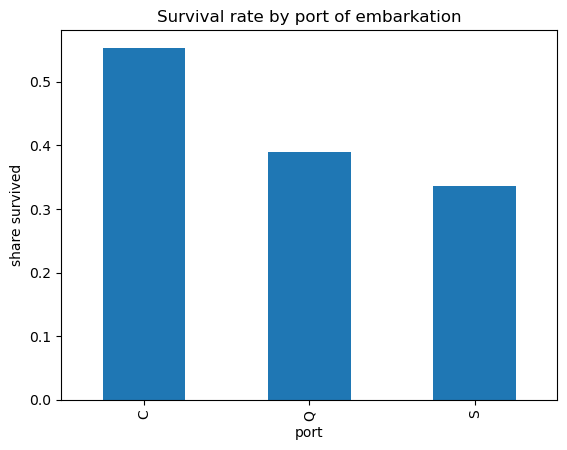

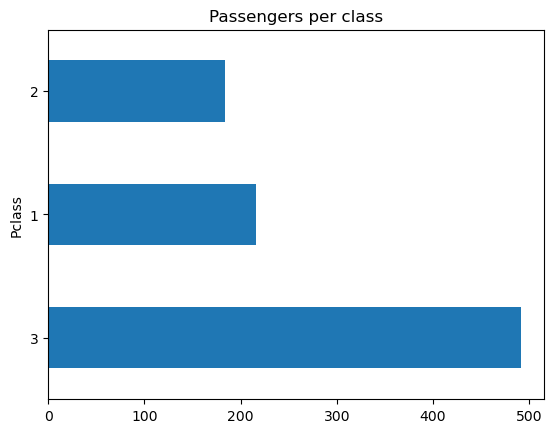

In [8]:
import matplotlib.pyplot as plt

df.groupby('Embarked')['Survived'].mean().plot(kind='bar')
plt.title('Survival rate by port of embarkation')
plt.xlabel('port')
plt.ylabel('share survived')
plt.show()

df['Pclass'].value_counts().plot(kind='barh')
plt.title('Passengers per class')
plt.show()

## Extra exercises

### 9. Titles (standard)

Every name contains a title (*Mr.*, *Mrs.*, *Miss.*, *Master.*, ...) between the comma and the full stop. Extract it into a new column `Title` with `.str.split(', ').str[1].str.split('.').str[0]` (split on the comma and space, take the second part, split on the full stop, take the first part), and show the counts of the titles. How many different titles are there?

In [9]:
df['Title'] = df['Name'].str.split(', ').str[1].str.split('.').str[0]
print(df['Title'].value_counts())
print(df['Title'].nunique())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64
17


### 10. Age groups (standard)

Write a function `age_group(age)` that returns `'child'` for ages under 12, `'adult'` for 12 and over, and `'unknown'` when the age is missing (a missing value is not equal to itself: `age != age` is `True` only for `NaN`; or use `pd.isna(age)`). Apply it to the `Age` column to make a column `AgeGroup`, and show the survival rate per age group.

In [10]:
def age_group(age):
    if pd.isna(age):
        return 'unknown'
    if age < 12:
        return 'child'
    return 'adult'

df['AgeGroup'] = df['Age'].apply(age_group)
print(df['AgeGroup'].value_counts())
print(df.groupby('AgeGroup')['Survived'].mean().round(3))

AgeGroup
adult      646
unknown    177
child       68
Name: count, dtype: int64
AgeGroup
adult      0.389
child      0.574
unknown    0.294
Name: Survived, dtype: float64


### 11. Missing ages (standard)

Which class has the most passengers with an unknown age? Make a mask with `.isna()`, filter, and count per class. Then compute the average age per class once on the full table and once on `df.dropna(subset=['Age'])`: why are the results the same?

In [11]:
print(df[df['Age'].isna()]['Pclass'].value_counts())
print(df.groupby('Pclass')['Age'].mean())
print(df.dropna(subset=['Age']).groupby('Pclass')['Age'].mean())
# .mean() skips missing values anyway, so dropping the rows changes nothing for the average.

Pclass
3    136
1     30
2     11
Name: count, dtype: int64
Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64
Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64


### 12. Another file (standard)

The file `bikes.csv` counts cyclists per day on several bicycle paths in Montreal. It is separated by semicolons and encoded in `latin-1`. Load it with the right `sep` and `encoding` arguments, show its shape and column names, and print the total number of cyclists counted on the path *Berri 1* and the date with the highest count on that path.

In [12]:
bikes = pd.read_csv('../../data/bikes.csv', sep=';', encoding='latin-1')
print(bikes.shape)
print(list(bikes.columns))
print(bikes['Berri 1'].sum())
print(bikes.loc[bikes['Berri 1'].idxmax(), 'Date'])

(310, 10)
['Date', 'Berri 1', 'Brébeuf (données non disponibles)', 'Côte-Sainte-Catherine', 'Maisonneuve 1', 'Maisonneuve 2', 'du Parc', 'Pierre-Dupuy', 'Rachel1', 'St-Urbain (données non disponibles)']
925365
15/06/2012


### 13. From text to table (harder)

Read `alice.txt`, tokenise it with `re.findall(r'[a-z]+', text.lower())` and count the tokens with a `Counter`. Turn the counter into a DataFrame with the columns `word` and `count`, add a column `length`, and answer: the ten most frequent words of at least seven letters; the average length of the words that occur only once versus the words that occur at least ten times (group by a boolean column).

In [13]:
import re
from collections import Counter

with open('../../data/alice.txt', encoding='utf-8') as infile:
    text = infile.read()

counts = Counter(re.findall(r'[a-z]+', text.lower()))
words = pd.DataFrame(counts.items(), columns=['word', 'count'])
words['length'] = words['word'].str.len()

print(words[words['length'] >= 7].sort_values('count', ascending=False).head(10))

words['frequent'] = words['count'] >= 10
print(words[(words['count'] == 1) | words['frequent']].groupby('frequent')['length'].mean().round(2))

             word  count  length
670       herself     83       7
595       thought     74       7
2516      gryphon     55       7
1103      duchess     42       7
2167     dormouse     40       8
587       nothing     34       7
1334      looking     32       7
3         project     31       7
1388      replied     29       7
1779  caterpillar     28      11
frequent
False    6.73
True     4.57
Name: length, dtype: float64


### 14. Save a subset (harder)

Make a table of the first-class passengers with the columns `Name`, `Sex`, `Age` and `Fare`, sorted by fare from high to low, and save it as `first_class.csv` without the index. Read the file back in and check that its shape is (216, 4).

In [14]:
first_class = df[df['Pclass'] == 1][['Name', 'Sex', 'Age', 'Fare']].sort_values('Fare', ascending=False)
first_class.to_csv('first_class.csv', index=False)

check = pd.read_csv('first_class.csv')
print(check.shape)
print(check.head(3))

(216, 4)
                                 Name     Sex   Age      Fare
0                    Ward, Miss. Anna  female  35.0  512.3292
1              Lesurer, Mr. Gustave J    male  35.0  512.3292
2  Cardeza, Mr. Thomas Drake Martinez    male  36.0  512.3292


### 15. Exam style: the Titanic in three steps (harder)

This exercise has the form of an exam question on a table: three steps of increasing difficulty.

(a) *Basic.* How many passengers are in the table, how many of them are women, and what is the average fare, rounded to two decimals?

(b) *Intermediate.* Add a column `FareGroup` that is `'cheap'` for fares below 10, `'medium'` for fares from 10 up to 50, and `'expensive'` for 50 and above (write a function and `.apply()` it). Show the survival rate per fare group, from lowest to highest.

(c) *Advanced.* For each class, what was the survival rate of women and of men, and how large is the difference between the two? Compute the rates with a two-column `groupby()`, and print, per class, the two rates and their difference, rounded to two decimals (loop over the classes 1, 2, 3 and use `.loc[(pclass, 'female')]` on the grouped result to read a value).

In [15]:
# (a)
print(len(df))
print(len(df[df['Sex'] == 'female']))
print(round(df['Fare'].mean(), 2))

# (b)
def fare_group(fare):
    if fare < 10:
        return 'cheap'
    if fare < 50:
        return 'medium'
    return 'expensive'

df['FareGroup'] = df['Fare'].apply(fare_group)
rates = df.groupby('FareGroup')['Survived'].mean()
print(rates[['cheap', 'medium', 'expensive']].round(3))

# (c)
by_class_and_sex = df.groupby(['Pclass', 'Sex'])['Survived'].mean()
for pclass in [1, 2, 3]:
    women = by_class_and_sex.loc[(pclass, 'female')]
    men = by_class_and_sex.loc[(pclass, 'male')]
    print(f'class {pclass}: women {women:.2f}, men {men:.2f}, difference {women - men:.2f}')

891
314
32.2
FareGroup
cheap        0.199
medium       0.421
expensive    0.677
Name: Survived, dtype: float64
class 1: women 0.97, men 0.37, difference 0.60
class 2: women 0.92, men 0.16, difference 0.76
class 3: women 0.50, men 0.14, difference 0.36


## Class exercises from the session notebook

Solutions to the exercises that are solved together during the session, for reference afterwards.

**Filters.** Under 18; under 18 in third class; survivors over 70.

In [16]:
import pandas as pd

df = pd.read_csv('../../data/titanic.csv')

print(len(df[df['Age'] < 18]))
print(len(df[(df['Age'] < 18) & (df['Pclass'] == 3)]))
print(df[(df['Age'] > 70) & (df['Survived'] == 1)][['Name', 'Age']])

113
78
                                     Name   Age
630  Barkworth, Mr. Algernon Henry Wilson  80.0


**Groups.** Average age per class; survival rate per port; children under 10 per class.

In [17]:
print(df.groupby('Pclass')['Age'].mean().round(1))
print(df.groupby('Embarked')['Survived'].mean().round(3))
print(df[df['Age'] < 10].groupby('Pclass').size())

Pclass
1    38.2
2    29.9
3    25.1
Name: Age, dtype: float64
Embarked
C    0.554
Q    0.390
S    0.337
Name: Survived, dtype: float64
Pclass
1     3
2    17
3    42
dtype: int64


**From text to table.** The ten most frequent words of more than six letters in Alice.

In [18]:
import re
from collections import Counter

with open('../../data/alice.txt', encoding='utf-8') as infile:
    text = infile.read()

counts = Counter(re.findall(r'[a-z]+', text.lower()))
words = pd.DataFrame(counts.items(), columns=['word', 'count'])
words['length'] = words['word'].str.len()
print(words[words['length'] > 6].sort_values('count', ascending=False).head(10))

             word  count  length
670       herself     83       7
595       thought     74       7
2516      gryphon     55       7
1103      duchess     42       7
2167     dormouse     40       8
587       nothing     34       7
1334      looking     32       7
3         project     31       7
1388      replied     29       7
1779  caterpillar     28      11
